In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import akshare as ak
import matplotlib.dates as mdates
from collections import defaultdict

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
data = ak.index_zh_a_hist(
    symbol='000985',
    start_date='20200101',
    end_date='20250101'
)

data['日期'] = pd.to_datetime(data['日期'])
data['market_return'] = data['收盘'].pct_change()
data['benchmark'] = (1 + data['market_return']).cumprod()
print(data.columns)

  0%|          | 0/17 [00:00<?, ?it/s]

Index(['日期', '开盘', '收盘', '最高', '最低', '成交量', '成交额', '振幅', '涨跌幅', '涨跌额', '换手率',
       'market_return', 'benchmark'],
      dtype='object')


In [3]:
def calc_price_bias(df: pd.DataFrame, n: int):
    ma = df['收盘'].rolling(window=n).mean()
    bias = (df['收盘'] - ma) / ma
    return bias

def calc_momentum(df: pd.DataFrame, n: int):
    return df['收盘'] / df['收盘'].shift(n) - 1

def calc_sharpe_ratio(df: pd.DataFrame, return_col='market_return', rf=0.02):
    df = df.copy()

    excess_return = df[return_col] - rf / 252

    mean_excess = excess_return.mean()
    std_excess = excess_return.std()

    if std_excess == 0:
        return 0

    sharpe = (mean_excess / std_excess) * (252 ** 0.5)

    return sharpe

In [4]:
def plot_box(df: pd.DataFrame, bench_sharpe: float, title: str):
    plt.figure(figsize=(10, 6))

    df.boxplot(grid=False,
               patch_artist=False,
               medianprops={'color': 'green', 'linewidth': 1.5})

    plt.axhline(y=bench_sharpe, color='r', linestyle='--', label='Benchmark (Buy & Hold)')

    plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

    plt.title(title, fontsize=12)
    plt.ylabel('Sharpe Ratio')
    plt.ylim(-1.5, 1.5)
    plt.legend()

    plt.show()

def plot_cum_result(df: pd.DataFrame):
        fig, ax1 = plt.subplots()

        ax1.xaxis.set_major_locator(mdates.YearLocator())
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

        ax1.plot(df['日期'], df['cum_return'])

        ax2 = ax1.twinx()
        ax2.plot(df['日期'], df['benchmark'], 'r-')

        y_min = min(df['cum_return'].min(), df['benchmark'].min())
        y_min *= 1.05
        y_max = max(df['cum_return'].max(), df['benchmark'].max())
        y_max *= 1.05

        ax1.set_ylim(y_min, y_max)
        ax2.set_ylim(ax1.get_ylim())

In [5]:
def boll_strategy(df: pd.DataFrame, indicator_calculator) -> (list, list):
    """
    Return the Sharpe ratios calculated from series of parameters.
    """
    k = 2

    df = df.copy()
    window_range = 30

    lst = []
    reverse_lst = []

    for window in range(3, window_range):
        df['indicator'] = indicator_calculator(df, window)
        df['signal'] = np.nan

        mb = df['indicator'].rolling(window=window).mean()
        std = df['indicator'].rolling(window=window).std()

        up = mb + k * std
        dn = mb - k * std

        rule1 = df['indicator'] <= dn
        rule2 = (df['indicator'].shift(1) < mb) & (df['indicator'] >= mb)

        rule3 = df['indicator'] >= up
        rule4 = (df['indicator'].shift(1) >= mb) & (df['indicator'] < mb)

        df.loc[(rule1 | rule2), 'signal'] = 1
        df.loc[(rule3 | rule4), 'signal'] = -1

        df['signal'] = df['signal'].ffill().fillna(0)

        df['trade_signal'] = df['signal'].shift(1)
        df['reverse_trade_signal'] = -df['trade_signal']

        df['strategy_return'] = df['trade_signal'] * df['market_return']
        df['reverse_strategy_return'] = df['reverse_trade_signal'] * df['market_return']

        df['cum_return'] = (1 + df['strategy_return']).cumprod()
        df['reverse_cum_return'] = (1 + df['reverse_strategy_return']).cumprod()

        lst.append(calc_sharpe_ratio(df, return_col='strategy_return'))
        reverse_lst.append(calc_sharpe_ratio(df, return_col='reverse_strategy_return'))

    return lst, reverse_lst

In [6]:
def momentum_strategy(df: pd.DataFrame, indicator_calculator) -> (list, list):
    df = df.copy()

    window_size = 20

    lst = []
    reverse_lst = []

    for window in range(5, window_size + 5):
        df['indicator'] = indicator_calculator(df, 20)

        ma_indicator = df['indicator'].rolling(window=window).mean()

        df['signal'] = np.where(df['indicator'] > ma_indicator, 1, -1)
        df['trade_signal'] = df['signal'].shift(1)
        df['reverse_trade_signal'] = -df['trade_signal']
        df['strategy_return'] = df['trade_signal'] * df['market_return']
        df['reverse_strategy_return'] = df['reverse_trade_signal'] * df['market_return']

        df['cum_return'] = (1 + df['strategy_return']).cumprod()
        df['reverse_cum_return'] = (1 + df['reverse_strategy_return']).cumprod()

        lst.append(calc_sharpe_ratio(df, return_col='strategy_return'))
        reverse_lst.append(calc_sharpe_ratio(df, return_col='reverse_strategy_return'))

    return lst, reverse_lst

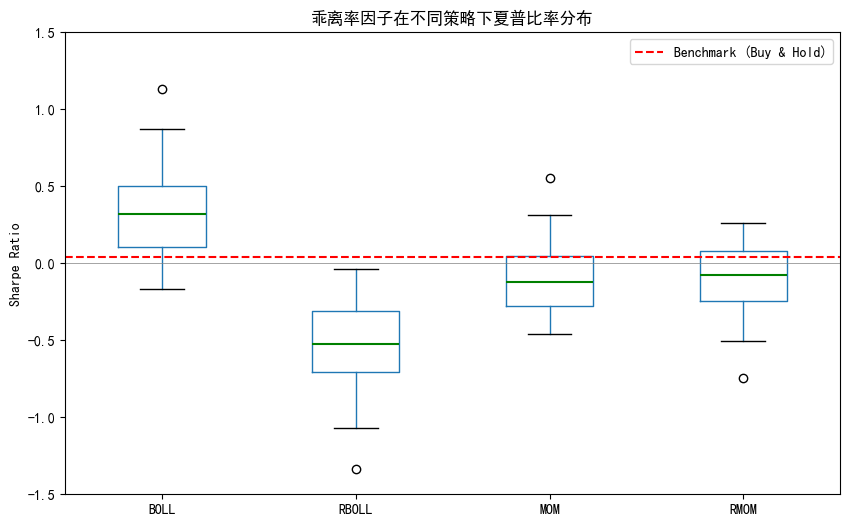

In [7]:
def backtest(df: pd.DataFrame):
    df = df.copy()

    bench_sharpe = calc_sharpe_ratio(df)
    result_map = defaultdict(lambda: defaultdict(list))

    result_map['BIAS']['BOLL'], result_map['BIAS']['RBOLL'] = boll_strategy(df, calc_price_bias)
    result_map['BIAS']['MOM'], result_map['BIAS']['RMOM'] = momentum_strategy(df, calc_price_bias)
    plot_box(pd.DataFrame({k: pd.Series(v) for k, v in result_map['BIAS'].items()}), bench_sharpe, title="乖离率因子在不同策略下夏普比率分布")

    result_map['MOMENTUM']['BOLL'], result_map['MOMENTUM']['RBOLL'] = boll_strategy(df, calc_momentum)

backtest(data)